### Supplementary analysis, early prediction and prediction of visit 4 from visit 2 in a set of SBPp and chronic participants, excluding SBPr.

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
# import os
# from Carl_Response_Functions.load_responses import *
import pandas as pd
import sklearn
from sklearn import linear_model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA, FastICA
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score


from nilearn import plotting
from nilearn import image
from nilearn import masking
from nilearn.image import concat_imgs
from sklearn.preprocessing import LabelEncoder
from nilearn.datasets import fetch_atlas_schaefer_2018
from nilearn.input_data import NiftiLabelsMasker
from nilearn.datasets import fetch_atlas_harvard_oxford
from nilearn.decoding import FREMClassifier

from nilearn.decoding import Decoder
from sklearn.model_selection import LeaveOneGroupOut
from nilearn.plotting import plot_stat_map, show
from nilearn.plotting import view_img
from nilearn.maskers import NiftiMasker

from nilearn.decoding import SearchLight
from sklearn.preprocessing import StandardScaler


from nilearn.glm import threshold_stats_img

import numpy as np
import nibabel as nib
from nilearn.input_data import NiftiLabelsMasker
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
import os
import subprocess
import matplotlib.pyplot as plt
from nilearn import plotting
from matplotlib.colors import ListedColormap

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from nilearn import plotting
import nibabel as nib
import seaborn as sns
import numpy as np

#Import classification models (SVM - Gradientboosting)
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier


from parcellation_to_classification_utils import *
from classification_functions import *
from fdr_correction_functions import *

#Change based on machine being used, for more information please refer to README "Running classification"
user = "gaia"

/homes/gp565/miniconda/envs/sbp_env/lib/python3.7/site-packages/nilearn/input_data/__init__.py:27: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  warnings.warn(message, FutureWarning)


In [2]:
#Retrieve paths used for analysis, path is based on user 
base_path, tian_atlas_path, tian_label_path, z_map_path, second_level_glm_path, run_mapping = obtain_base_paths(user)

# Load the Schaefer atlas (assuming get_schaefer_parcellation is defined)
schaefer_img, schaefer_labels = get_schaefer_parcellation(n_rois=200)

# Load the Tian atlas (assuming get_tian_parcellation is defined)
tian_img, tian_labels = get_tian_parcellation(tian_atlas_path, tian_label_path)

# Combine the atlases (assuming combine_parcellations is defined)
combined_img, combined_labels = combine_parcellations(schaefer_img, tian_img, schaefer_labels, tian_labels)

### Select chronic and SBPp, exclude SBPr

In [3]:

#Select subjects for classification
S_all = select_subject_id_and_group_label(z_map_path, second_level_glm_path, run_map = run_mapping)

1 3
2 3
3 4
4 4
5 4
6 4
7 4
8 4
9 4
10 4
11 4
12 3
13 4
14 4
15 4
16 4
17 4
18 4
19 4
20 3
21 4
22 4
23 4
24 4
25 4
26 4
27 3
28 4
29 4
31 4
32 4
33 4
34 4
35 4
36 4
37 4
38 4
39 4
40 4
41 4
42 3
43 4
44 4
45 4
46 3
47 4
48 4
49 4
50 4
51 4
52 4
53 4
54 4
55 4
56 4
57 3
58 3
59 4
60 3
61 4
62 4
63 3
64 4
65 4
66 3
67 4
68 4
69 4
70 4
71 0
72 0
73 0
74 0
75 0
76 0
77 0
78 0
79 0
80 0
81 0
82 0
83 0
84 0
85 0
86 0
87 0
88 0
89 0
90 0
91 0
92 0
93 0
94 0


### GBM early prediction

In [11]:
from sklearn.ensemble import GradientBoostingClassifier

# Define your classifier
classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state = 0)

classifier_name = "GradientBoostingClassifier"
    
# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

early_prediction = "1_and_4"

# Run main function if script is executed
if __name__ == "__main__":
    no_recovery_main(classifier, visit_range, classifier_name, z_map_path, run_mapping, S_all = S_all, base_path = base_path,
    tian_atlas_path = tian_atlas_path, tian_label_path = tian_label_path, visit_selection = early_prediction,
    distribution = "Real", selected_labels_csv_path="with_chronic_selected_subjects_labels.csv")
    #, selected_labels_csv_path = "not_sbpr_selected_subjects_labels.csv"

Iteration 0
Results saved to: /scratch/gp565/sbp/Results/fMRI_Classifiers_Output/GradientBoostingClassifier/Real_data/GradientBoostingClassifier_with_chronics_early_prediction.json


Permutation test

In [13]:
from sklearn.ensemble import GradientBoostingClassifier

# Define your classifier
classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=0)

classifier_name = "GradientBoostingClassifier"

# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

early_prediction = "1_and_4"

iteration_n = 700

# Run main function if script is executed
if __name__ == "__main__":
    with_chronic_null_main(classifier,
        visit_range,
        classifier_name,
        z_map_path,
        run_mapping=run_mapping,
        iters=iteration_n,
        S_all = S_all,
        base_path = base_path,
        tian_atlas_path = tian_atlas_path,
        tian_label_path = tian_label_path,
        visit_selection=early_prediction,
        selected_labels_csv_path = "with_chronic_selected_subjects_labels.csv")

Iteration 0
Iteration 10
Iteration 20
Iteration 30
Iteration 40
Iteration 50
Iteration 60
Iteration 70
Iteration 80
Iteration 90
Iteration 100
Iteration 110
Iteration 120
Iteration 130
Iteration 140
Iteration 150
Iteration 160
Iteration 170
Iteration 180
Iteration 190
Iteration 200
Iteration 210
Iteration 220
Iteration 230
Iteration 240
Iteration 250
Iteration 260
Iteration 270
Iteration 280
Iteration 290
Iteration 300
Iteration 310
Iteration 320
Iteration 330
Iteration 340
Iteration 350
Iteration 360
Iteration 370
Iteration 380
Iteration 390
Iteration 400
Iteration 410
Iteration 420
Iteration 430
Iteration 440
Iteration 450
Iteration 460
Iteration 470
Iteration 480
Iteration 490
Iteration 500
Iteration 510
Iteration 520
Iteration 530
Iteration 540
Iteration 550
Iteration 560
Iteration 570
Iteration 580
Iteration 590
Iteration 600
Iteration 610
Iteration 620
Iteration 630
Iteration 640
Iteration 650
Iteration 660
Iteration 670
Iteration 680
Iteration 690
Results saved to: /scratch/gp56

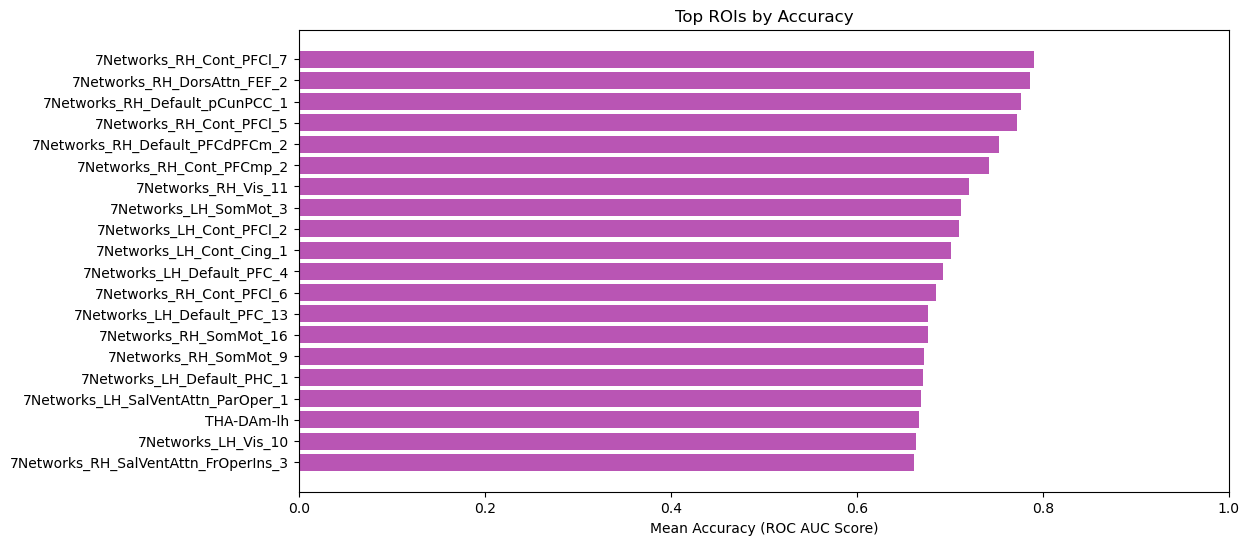

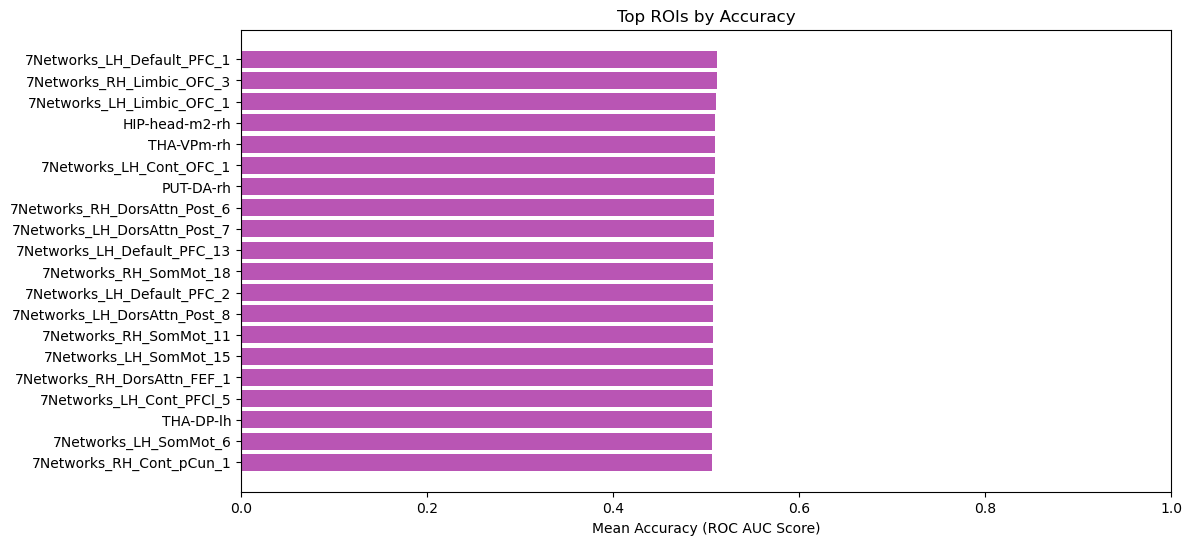

In [4]:
#Path to GBM output
gbm_performance = pd.read_json("Results/fMRI_Classifiers_Output/GradientBoostingClassifier/Real_data/GradientBoostingClassifier_with_chronics_early_prediction.json")

gbm_null_performance = pd.read_json("Results/fMRI_Classifiers_Output/GradientBoostingClassifier/Null_data/GradientBoostingClassifier_with_chronics_early_prediction_null.json")

#number of top parcels to consider
nr_top_parcels = 20

#Setup info of GBM, df of GBM output, nr_top_parcels parcels considered from GBM output
gbm_null_setup_info, gbm_null_classifier_df, gbm_null_top_parcels = display_top_ROIs_from_classifier(gbm_null_performance, nr_top_parcels,
                                                                                                     setup = True)

gbm_setup_info, gbm_classifier_df, gbm_top_parcels = display_top_ROIs_from_classifier(gbm_performance, nr_top_parcels,
                                                                                                     setup=True)

# --- Visualise violin plots of mean performance per iteration, top 20 combined atlas glass, and top5 glass brain
#visualize_top_rois_from_performance_df(gbm_null_classifier_df, combined_labels, combined_img, top_n=20)

# -- Display the average confusion matrix (across n iterations, each y folds) per top 20 parcels
#confusion_matrix_per_fold(svc_top_parcels)


barplot_top_ROIs(gbm_classifier_df, nr_top_parcels, model_used = "GBM")
barplot_top_ROIs(gbm_null_classifier_df, nr_top_parcels, model_used = "GBM")

In [5]:
#Classifier name
classifier_name = "GradientBoostingClassifier"

#Obtain results of permutation test (empirical p-values)
gbm_permutatation_test_results = permutation_test(gbm_null_classifier_df, gbm_classifier_df)

#Pick number of parcels to study
nr_top_parcels = 20 

# Filter by those results that are below 0.05
significant_results = gbm_permutatation_test_results[gbm_permutatation_test_results["p_value"] < 0.05]

# Then sort and take top N (up to nr_top_parcels)
gbm_top_permutation = significant_results.sort_values(by="p_value", ascending=True).head(nr_top_parcels)

# Generate path to store the significant parcels df 
save_path = generate_output_significant_parcels(base_path, classifier_name, "fMRI")

#By default, the values are saved in Intermediate_Files under classifier_name dir
gbm_top_permutation.to_csv(os.path.join(save_path, "gbm_with_chronics_significant_parcels_df"), index=False)


 FDR correction 

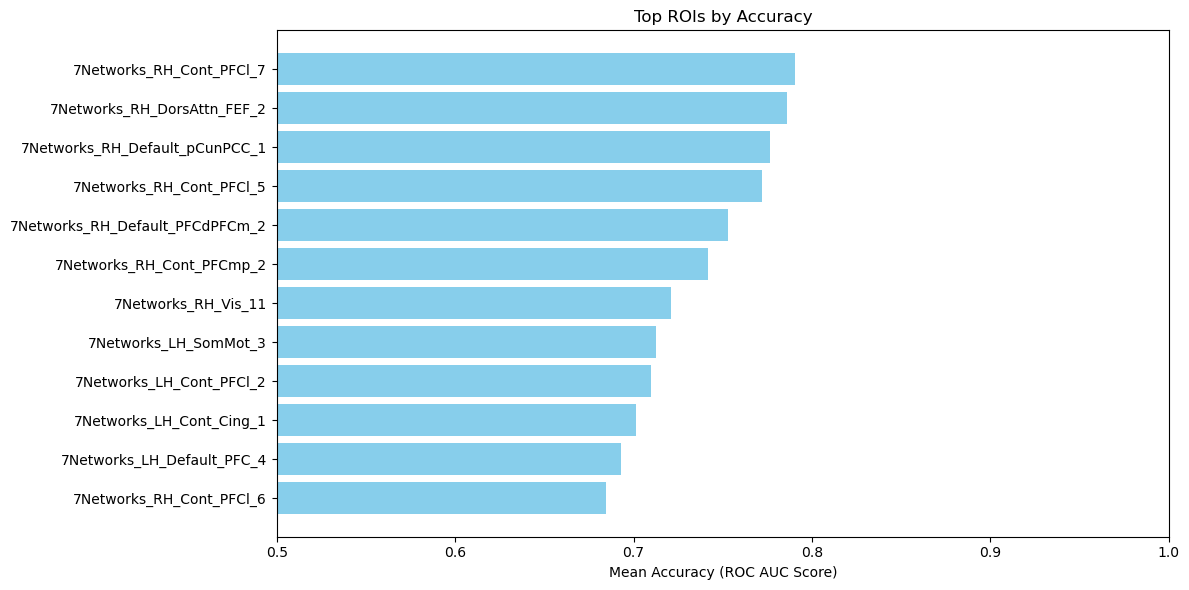

In [5]:
gbm_bh_significant = pd.read_csv("/scratch/gp565/sbp/Results/Intermediate_Files/fMRI_Classifiers_Significant_Output/GradientBoostingClassifier/gbm_with_chronics_significant_parcels_df")
gbm_bh_significant = benjamini_hochberg(gbm_bh_significant, model="GBM", prediction ="early_prediction")

7Networks_RH_Cont_PFCl_7
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/GBM_early_pred_with_chronic/7Networks_RH_Cont_PFCl_7_mask.nii.gz
7Networks_RH_DorsAttn_FEF_2
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/GBM_early_pred_with_chronic/7Networks_RH_DorsAttn_FEF_2_mask.nii.gz
7Networks_RH_Default_pCunPCC_1
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/GBM_early_pred_with_chronic/7Networks_RH_Default_pCunPCC_1_mask.nii.gz
7Networks_RH_Cont_PFCl_5
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/GBM_early_pred_with_chronic/7Networks_RH_Cont_PFCl_5_mask.nii.gz
7Networks_RH_Default_PFCdPFCm_2
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/GBM_early_pred_with_chronic/7Networks_RH_Default_PFCdPFCm_2_mask.nii.gz
7Networks_RH_Cont_PFCmp_2
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/GBM_early_pred_with_chronic/7Networks_RH_Cont_PFCmp_2_mask.nii.gz
7Networks_RH_Vis_11
Saved: /scratch/gp565/sbp/Re

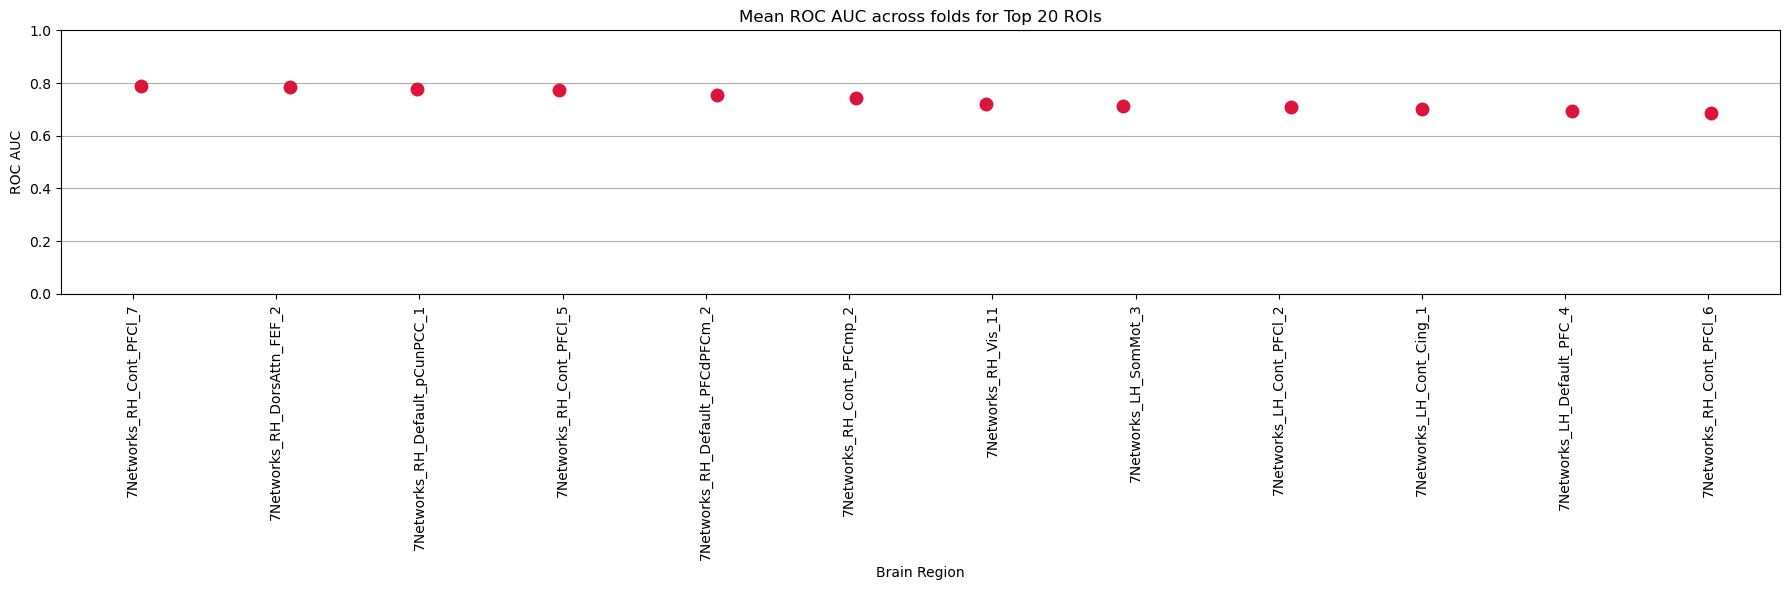

/homes/gp565/miniconda/envs/sbp_env/lib/python3.7/site-packages/nilearn/plotting/img_plotting.py:300: FutureWarning: Default resolution of the MNI template will change from 2mm to 1mm in version 0.10.0
  anat_img = load_mni152_template()


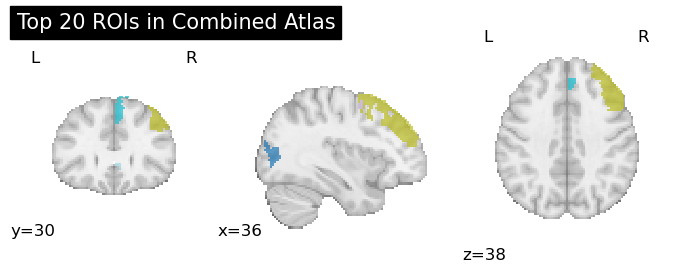

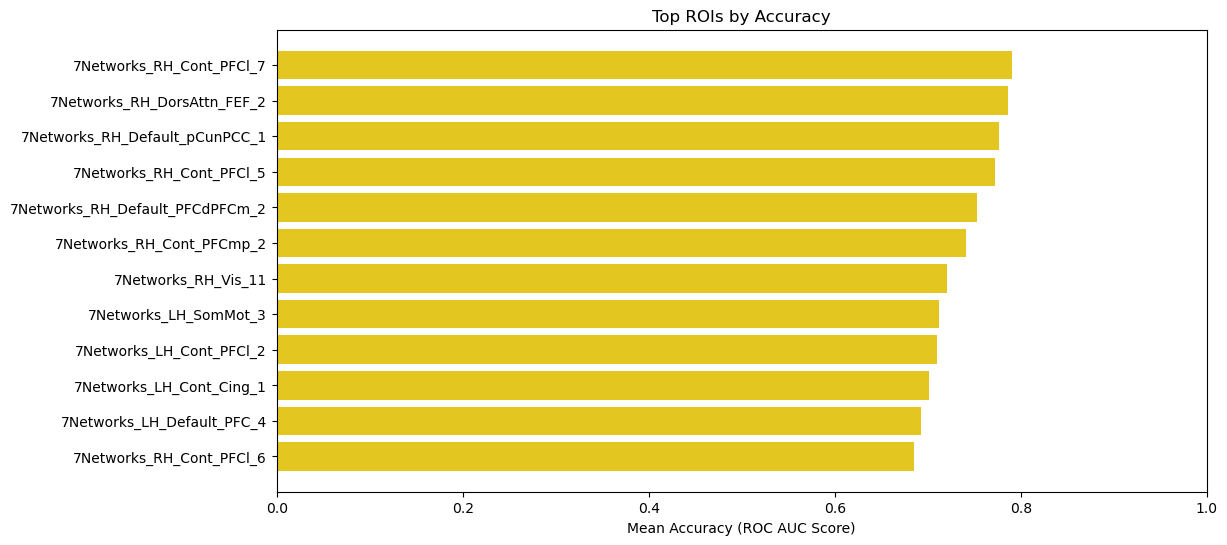

In [6]:
#number of top parcels to consider
nr_top_parcels = 20

# --- Visualise violin plots of mean performance per iteration, top 20 combined atlas glass, and top5 glass brain
visualize_top_rois_from_performance_df(gbm_bh_significant, base_path, combined_labels, 
                                       combined_img,
                                        model ="GBM_early_pred_with_chronic", top_n=nr_top_parcels,
                                       save_nifti = True)

# -- Display the average confusion matrix (across n iterations, each y folds) per top 20 parcels
# confusion_matrix_per_fold(gbm_top_parcels)

barplot_top_ROIs(gbm_bh_significant, nr_top_parcels, model_used = "GBM_early_with_chronic")

In [7]:
gbm_bh_significant_copy = gbm_bh_significant.copy()
gbm_bh_significant = parcel_to_network_name(gbm_bh_significant_copy)

In [16]:
extract_coordinates_from_nifti(base_path, model="GBM", type_prediction = "early_pred_with_chronic")


=== ROI Center MNI Coordinates ===



[('7Networks_LH_Cont_Cing_1', array([ -4.69, -28.88,  26.88])),
 ('7Networks_LH_Cont_PFCl_2', array([-27.54,  58.03,   8.04])),
 ('7Networks_LH_Default_PFC_4', array([-13.25,  62.56,  -5.7 ])),
 ('7Networks_LH_SomMot_3', array([-36.92, -20.96,  15.28])),
 ('7Networks_RH_Cont_PFCl_5', array([29.73, 48.13, 27.12])),
 ('7Networks_RH_Cont_PFCl_7', array([42.13, 14.28, 48.97])),
 ('7Networks_RH_Cont_PFCmp_2', array([ 7.85, 25.58, 54.74])),
 ('7Networks_RH_Default_PFCdPFCm_2', array([ 7.89, 41.93,  4.03])),
 ('7Networks_RH_Default_pCunPCC_1', array([ 12.85, -54.55,  15.02])),
 ('7Networks_RH_DorsAttn_FEF_2', array([25.98,  7.09, 57.66])),
 ('7Networks_RH_Vis_11', array([ 42.25, -79.83,   9.7 ]))]

In [ ]:
no_SBPr_early_pred_mapping = {
            "7Networks_LH_Cont_Cing_1":"CG, L", #Cingulate Gyrus #89% FSL eyes estimate
            "7Networks_LH_Cont_PFCl_2": "vmPFC, L",#"Ventromedial prefrontal cortex",
            "7Networks_LH_Default_PFC_4": "PFC, L",#"Prefrontal cortex",
            "7Networks_LH_SomMot_3":"fO, L",#frontal operculum
            "7Networks_RH_Cont_PFCl_5":"mPFC, R",#Medial frontal cortex
            "7Networks_RH_Cont_PFCl_7": "pre-SMA, R", #Pre-supplementary motor area
            "7Networks_RH_Cont_PFCmp_2": "SFG, R",#Superior Frontal Gyrus
            "7Networks_RH_Default_PFCdPFCm_2": "ACC, R", #ant cingulate cortex
            "7Networks_RH_Default_pCunPCC_1": "PCC, R", #posterior cingulate cortex
            "7Networks_RH_DorsAttn_FEF_2" : "MFG, R",#Middle frontal gyrus
            "7Networks_RH_Vis_11":"V1, R",
            "7Networks_RH_Cont_PFCl_6":"lMFG, R"
            }

MNI152 coordinates (mm):
[40.62946429 32.95535714 37.24553571]


This is template code for the case you cannot find the coordinates of a region, you can look them using nifti and calculatin e centre of data of the nib file.

#Run this in case one region does not correctly
`
`from scipy.ndimage import center_of_mass`

`img = nib.load("Results/Intermediate_Files/mz3_files/GBM_early_pred_with_chronic/7Networks_RH_Cont_PFCl_6_mask.nii.gz")`

`data = img.get_fdata()`

`# center of mass in voxel coordinates`
`com_voxel = center_of_mass(data)`

`# convert to MNI/world coordinates`
`com_mni = nib.affines.apply_affine(img.affine, com_voxel)`

`print("MNI152 coordinates (mm):")`
`print(com_mni)`

1     0 - pre-SMA, R
0         0 - MFG, R
2         0 - PCC, R
3        0 - mPFC, R
4         0 - ACC, R
5         0 - SFG, R
8          0 - V1, R
7          0 - fO, L
6       0 - vmPFC, L
10         0 - CG, L
9         0 - PFC, L
11       0 - lMFG, R
Name: plot_label, dtype: object


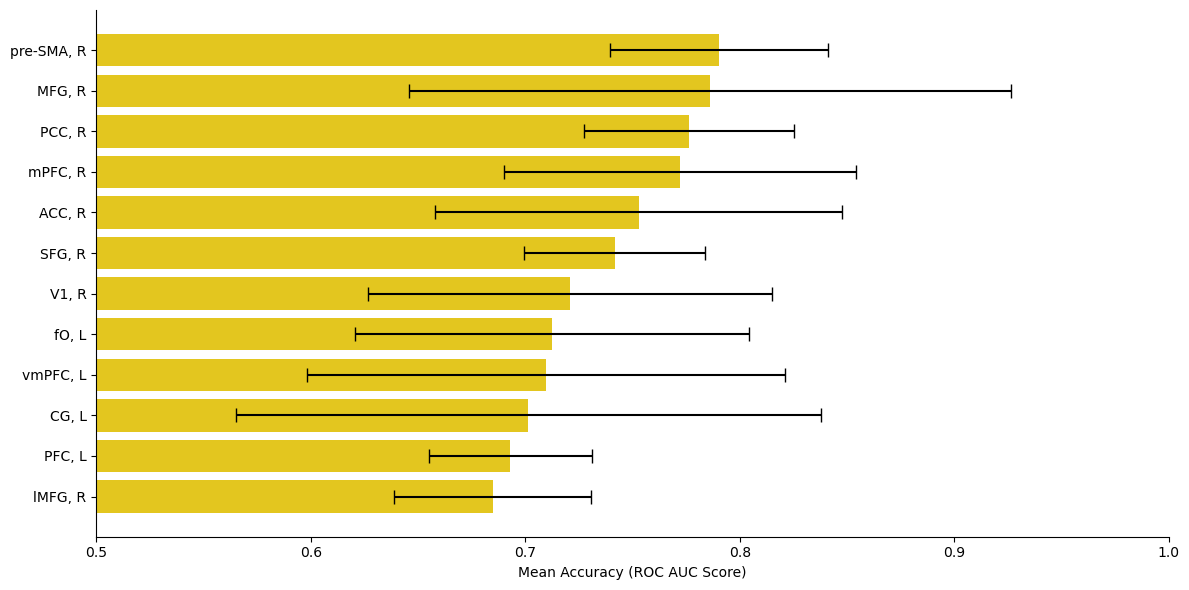

In [15]:
plot_human_labels(gbm_bh_significant, base_path, no_SBPr_early_pred_mapping,
                   model="early_pred_GBM", prediction="with_chronics", FDR_method="BH", error_bar = True)

### GBM - visit 2 predicts visit 4

In [4]:
from sklearn.ensemble import GradientBoostingClassifier

# Define your classifier
classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state = 0)

classifier_name = "GradientBoostingClassifier"
    
# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

type_prediction = "visit_2"

# Run main function if script is executed
if __name__ == "__main__":
    no_recovery_main(classifier, visit_range, classifier_name, z_map_path, run_mapping, S_all = S_all, base_path = base_path,
    tian_atlas_path = tian_atlas_path, tian_label_path = tian_label_path, visit_selection = type_prediction,
    distribution = "Real", selected_labels_csv_path="with_chronic_selected_subjects_labels.csv")

Iteration 0
Results saved to: /scratch/gp565/sbp/Results/fMRI_Classifiers_Output/GradientBoostingClassifier/Real_data/GradientBoostingClassifier_with_chronics_visit_2.json


Permutation test

In [5]:
from sklearn.ensemble import GradientBoostingClassifier

# Define your classifier
classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=0)

classifier_name = "GradientBoostingClassifier"

# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

type_prediction = "visit_2"

iteration_n = 700

# Run main function if script is executed
if __name__ == "__main__":
    with_chronic_null_main(classifier,
        visit_range,
        classifier_name,
        z_map_path,
        run_mapping=run_mapping,
        iters=iteration_n,
        S_all = S_all,
        base_path = base_path,
        tian_atlas_path = tian_atlas_path,
        tian_label_path = tian_label_path,
        visit_selection=type_prediction,
        selected_labels_csv_path = "with_chronic_selected_subjects_labels.csv")

Iteration 0
Iteration 10
Iteration 20
Iteration 30
Iteration 40
Iteration 50
Iteration 60
Iteration 70
Iteration 80
Iteration 90
Iteration 100
Iteration 110
Iteration 120
Iteration 130
Iteration 140
Iteration 150
Iteration 160
Iteration 170
Iteration 180
Iteration 190
Iteration 200
Iteration 210
Iteration 220
Iteration 230
Iteration 240
Iteration 250
Iteration 260
Iteration 270
Iteration 280
Iteration 290
Iteration 300
Iteration 310
Iteration 320
Iteration 330
Iteration 340
Iteration 350
Iteration 360
Iteration 370
Iteration 380
Iteration 390
Iteration 400
Iteration 410
Iteration 420
Iteration 430
Iteration 440
Iteration 450
Iteration 460
Iteration 470
Iteration 480
Iteration 490
Iteration 500
Iteration 510
Iteration 520
Iteration 530
Iteration 540
Iteration 550
Iteration 560
Iteration 570
Iteration 580
Iteration 590
Iteration 600
Iteration 610
Iteration 620
Iteration 630
Iteration 640
Iteration 650
Iteration 660
Iteration 670
Iteration 680
Iteration 690
Results saved to: /scratch/gp56

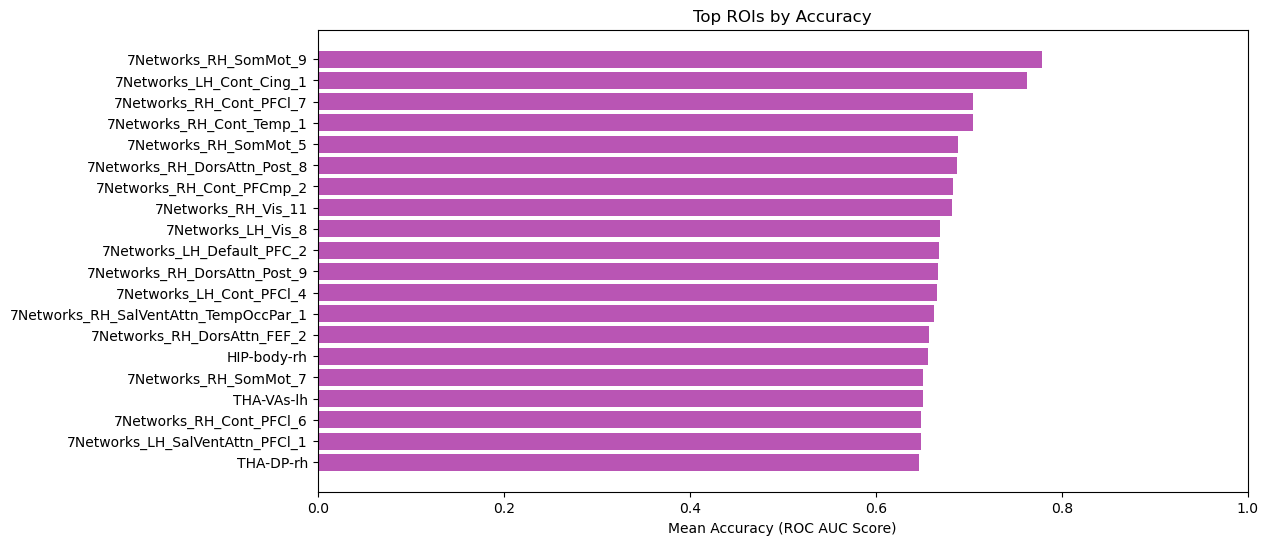

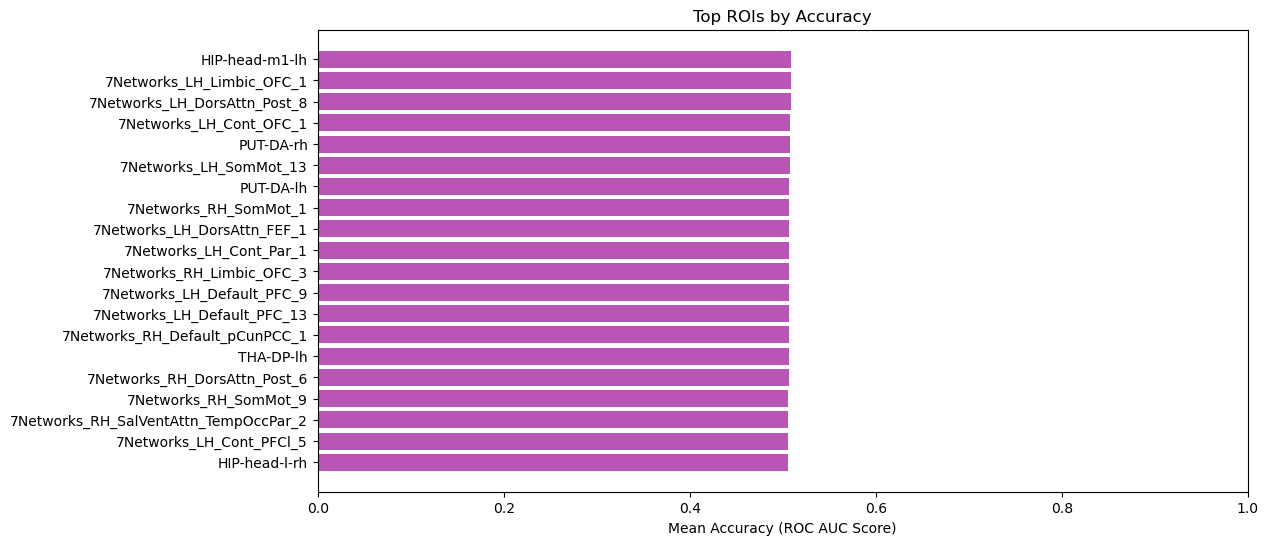

In [4]:
#Path to GBM output
gbm_performance_visit2 = pd.read_json("Results/fMRI_Classifiers_Output/GradientBoostingClassifier/Real_data/GradientBoostingClassifier_with_chronics_visit_2.json")

gbm_null_performance_visit2 = pd.read_json("Results/fMRI_Classifiers_Output/GradientBoostingClassifier/Null_data/GradientBoostingClassifier_with_chronics_visit_2_null.json")

#number of top parcels to consider
nr_top_parcels = 20

#Setup info of GBM, df of GBM output, nr_top_parcels parcels considered from GBM output
gbm_null_setup_info_visit2, gbm_null_classifier_visit2_df, gbm_null_visit2_top_parcels = display_top_ROIs_from_classifier(gbm_null_performance_visit2, nr_top_parcels,
                                                                                                     setup = True)

gbm_setup_info_visit2, gbm_classifier_visit2_df, gbm__visit2_top_parcels = display_top_ROIs_from_classifier(gbm_performance_visit2, nr_top_parcels,
                                                                                                     setup=True)

# --- Visualise violin plots of mean performance per iteration, top 20 combined atlas glass, and top5 glass brain
#visualize_top_rois_from_performance_df(gbm_null_classifier_df, combined_labels, combined_img, top_n=20)

# -- Display the average confusion matrix (across n iterations, each y folds) per top 20 parcels
#confusion_matrix_per_fold(svc_top_parcels)


barplot_top_ROIs(gbm_classifier_visit2_df, nr_top_parcels, model_used = "GBM")
barplot_top_ROIs(gbm_null_classifier_visit2_df, nr_top_parcels, model_used = "GBM")

In [5]:
#Classifier name
classifier_name = "GradientBoostingClassifier"

#Obtain results of permutation test (empirical p-values)
gbm_visit2_permutation_test_results = permutation_test(gbm_null_classifier_visit2_df, gbm_classifier_visit2_df)

#Pick number of parcels to study
nr_top_parcels = 20 

# Filter by those results that are below 0.05
significant_results_visit2 = gbm_visit2_permutation_test_results[gbm_visit2_permutation_test_results["p_value"] < 0.05]

# Then sort and take top N (up to nr_top_parcels)
gbm_visit2_top_permutation = significant_results_visit2.sort_values(by="p_value", ascending=True).head(nr_top_parcels)

# Generate path to store the significant parcels df 
save_path = generate_output_significant_parcels(base_path, classifier_name, "fMRI")

#By default, the values are saved in Intermediate_Files under classifier_name dir
gbm_visit2_top_permutation.to_csv(os.path.join(save_path, "gbm_with_chronics_significant_parcels_visit2_df"), index=False)


FDR correction

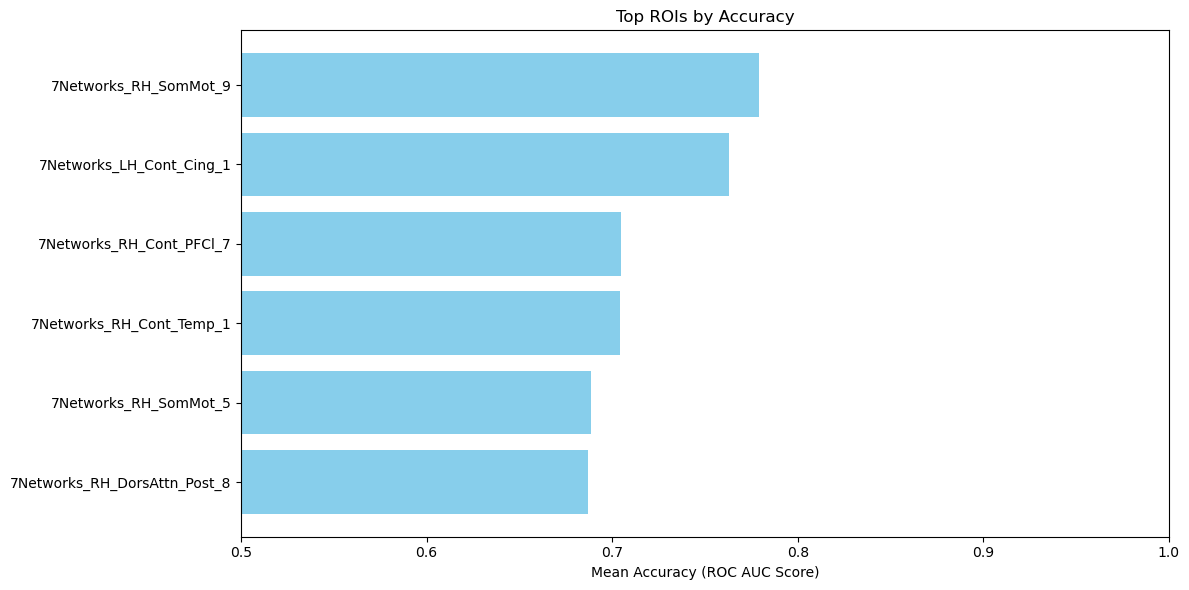

In [10]:
gbm_bh_significant_visit2 = pd.read_csv("/scratch/gp565/sbp/Results/Intermediate_Files/fMRI_Classifiers_Significant_Output/GradientBoostingClassifier/gbm_with_chronics_significant_parcels_visit2_df")
gbm_bh_significant_visit2 = benjamini_hochberg(gbm_bh_significant_visit2, model="GBM", prediction ="visit_2")

Plot performance of algorithm that survives FDR correction

7Networks_RH_SomMot_9
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/visit2_with_chronic_GBM/7Networks_RH_SomMot_9_mask.nii.gz
7Networks_LH_Cont_Cing_1
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/visit2_with_chronic_GBM/7Networks_LH_Cont_Cing_1_mask.nii.gz
7Networks_RH_Cont_PFCl_7
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/visit2_with_chronic_GBM/7Networks_RH_Cont_PFCl_7_mask.nii.gz
7Networks_RH_Cont_Temp_1
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/visit2_with_chronic_GBM/7Networks_RH_Cont_Temp_1_mask.nii.gz
7Networks_RH_SomMot_5
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/visit2_with_chronic_GBM/7Networks_RH_SomMot_5_mask.nii.gz
7Networks_RH_DorsAttn_Post_8
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/visit2_with_chronic_GBM/7Networks_RH_DorsAttn_Post_8_mask.nii.gz


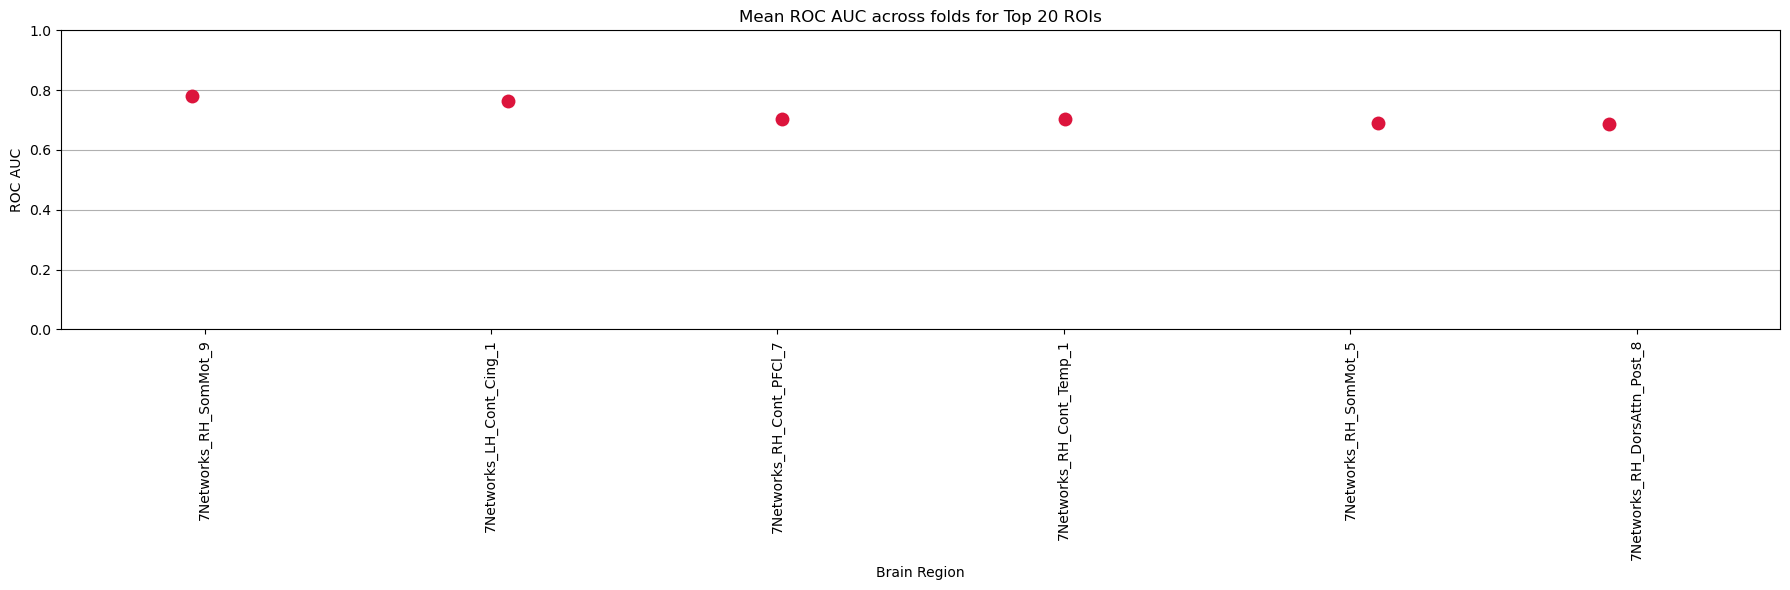

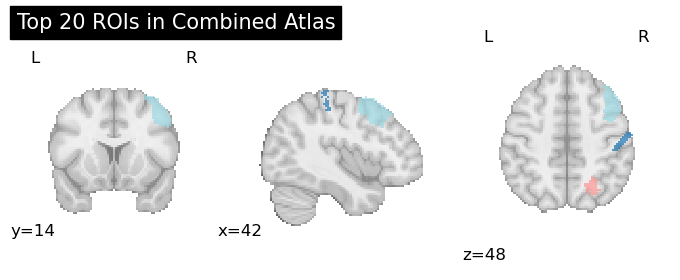

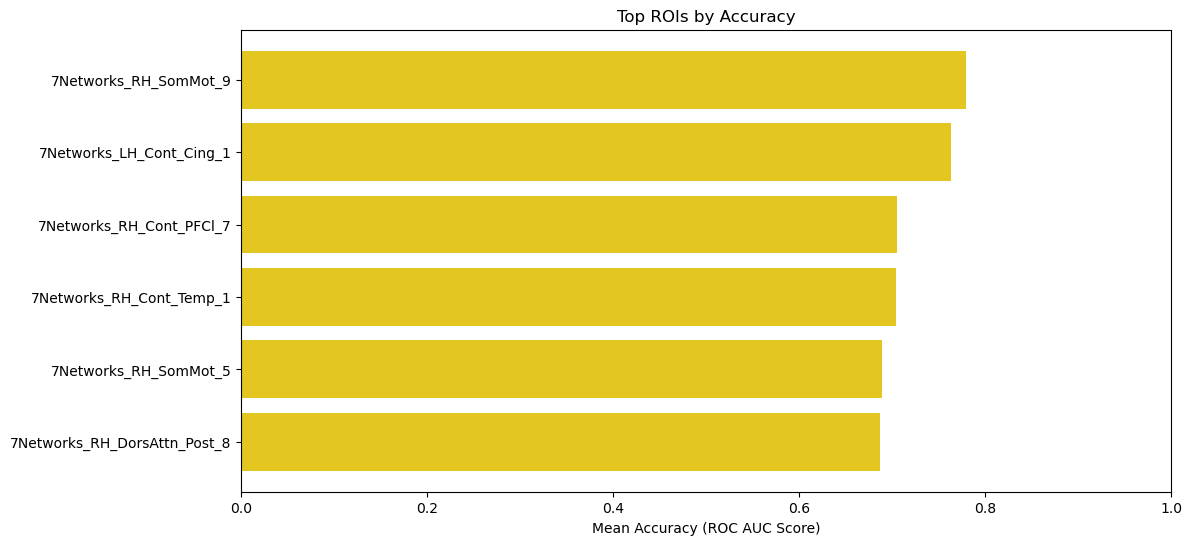

In [11]:
#number of top parcels to consider
nr_top_parcels = 20

# --- Visualise violin plots of mean performance per iteration, top 20 combined atlas glass, and top5 glass brain
visualize_top_rois_from_performance_df(gbm_bh_significant_visit2, base_path, combined_labels, 
                                       combined_img,
                                        model ="visit2_with_chronic_GBM", top_n=nr_top_parcels,
                                       save_nifti = True)

# -- Display the average confusion matrix (across n iterations, each y folds) per top 20 parcels
# confusion_matrix_per_fold(gbm_top_parcels)

barplot_top_ROIs(gbm_bh_significant_visit2, nr_top_parcels, model_used = "visit2_with_chronic_GBM")

Extract coordinates

In [12]:
visit2_gbm_bh_significant_copy = gbm_bh_significant_visit2.copy()
visit2_gbm_bh_significant = parcel_to_network_name(visit2_gbm_bh_significant_copy)

extract_coordinates_from_nifti(base_path, model="GBM", type_prediction = "visit2_with_chronic")


=== ROI Center MNI Coordinates ===



[('7Networks_LH_Cont_Cing_1', array([ -4.69, -28.88,  26.88])),
 ('7Networks_RH_Cont_PFCl_7', array([42.13, 14.28, 48.97])),
 ('7Networks_RH_Cont_Temp_1', array([ 62.59, -41.91, -11.43])),
 ('7Networks_RH_DorsAttn_Post_8', array([ 26.26, -61.28,  57.97])),
 ('7Networks_RH_SomMot_5', array([59.01,  0.55, 10.93])),
 ('7Networks_RH_SomMot_9', array([ 50.9 , -22.41,  51.84]))]

In [ ]:
no_SBPr_visit2_mapping = {
            "7Networks_LH_Cont_Cing_1":"PCC, L", #posterior cingulate gyrus
            "7Networks_RH_Cont_PFCl_7":"PMC, R", #premotor cortex
            "7Networks_RH_Cont_Temp_1":"ITG, R",#Inferior Temporal Gyrus, temporooccipital part 
            "7Networks_RH_DorsAttn_Post_8":"V1, R",
            "7Networks_RH_SomMot_5":"prCG, R", #precentral gyrus
            "7Networks_RH_SomMot_9":"POG, R", #postcentral gyrus
                }

1     0 - POG, R
0     0 - PCC, L
2     0 - PMC, R
4     0 - ITG, R
3    0 - prCG, R
5      0 - V1, R
Name: plot_label, dtype: object


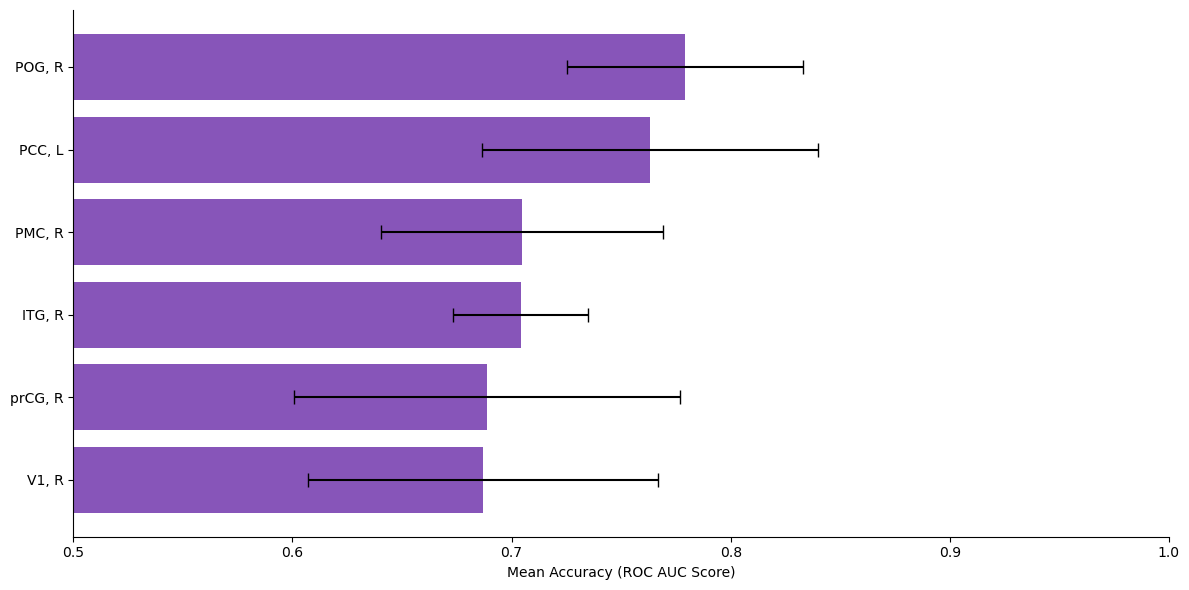

In [15]:
plot_human_labels(visit2_gbm_bh_significant, base_path, no_SBPr_visit2_mapping,
                   model="visit2_GBM", prediction="with_chronics", FDR_method="BH", error_bar = True)